# 处理包头鑫元1000方数据

In [ ]:
import pandas as pd
import numpy as np
import math

from utils.keys import Cols

In [ ]:
df_01 = pd.read_excel(r'D:\\Devs\\Single_Stack_MLJ\\data\\raw\\XINYUAN\\包头1000方数据1#2025-12.01-12.30.xlsx', header=1)
df_02 = pd.read_excel(r'D:\\Devs\\Single_Stack_MLJ\\data\\raw\\XINYUAN\\包头1000方数据1#2026-01.22-02.06.xlsx', header=1)
df_03 = pd.read_excel(r'D:\\Devs\\Single_Stack_MLJ\\data\\raw\\XINYUAN\\包头1000方数据1#2026-02.12-03.12.xlsx', header=1)

In [ ]:
COLUMN_MAPPING = {
    "日期": Cols.date_time,
    "系统压力Mpa": Cols.pressure,
    "碱液流量m³/h": Cols.lye_flow,
    "碱温℃": Cols.lye_temp,
    "氧槽温℃": Cols.temp_O,
    "氢槽温℃": Cols.temp_H,
    "槽电流A": Cols.current,
    "槽电压V": Cols.voltage,
    "氧中氢%": Cols.HTO,
    "氢中氧%": Cols.OTH
}

num_cells = 280

Width_Cell = 12E-3

electrode_diameter = 1832E-3

electrode_area = math.pi * (electrode_diameter / 2) ** 2

## 数据处理

In [ ]:
# 按 COLUMN_MAPPING 重命名列名
def preprocess_raw_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.rename(columns=COLUMN_MAPPING)
    df = df.drop(columns=['序号'])
    return df.reset_index(drop=True)

df_01 = preprocess_raw_data(df_01)
df_02 = preprocess_raw_data(df_02)
df_03 = preprocess_raw_data(df_03)

## 计算衍生变量

In [ ]:
df_01[Cols.temp_out] = (df_01[Cols.temp_H] + df_01[Cols.temp_O]) / 2

df_01[Cols.cell_voltage] = df_01[Cols.voltage] / num_cells

df_01[Cols.current_density] = df_01[Cols.current] / electrode_area

In [ ]:
df_02[Cols.temp_out] = (df_02[Cols.temp_H] + df_02[Cols.temp_O]) / 2

df_02[Cols.cell_voltage] = df_02[Cols.voltage] / num_cells

df_02[Cols.current_density] = df_02[Cols.current] / electrode_area

In [ ]:
df_03[Cols.temp_out] = (df_03[Cols.temp_H] + df_03[Cols.temp_O]) / 2

df_03[Cols.cell_voltage] = df_03[Cols.voltage] / num_cells

df_03[Cols.current_density] = df_03[Cols.current] / electrode_area

## 按gzip格式保存数据

In [ ]:
from pathlib import Path
import gzip
import pickle

output_dir = Path(r"D:\Devs\Single_Stack_MLJ\data\processed\XINYUAN")
output_dir.mkdir(parents=True, exist_ok=True)

save_targets = {
    "包头1000方数据1#2025-12.01-12.30 gzip": df_01,
    "包头1000方数据1#2026-01.22-02.06 gzip": df_02,
    "包头1000方数据1#2026-02.12-03.12 gzip": df_03,
}

for file_name, df in save_targets.items():
    output_path = output_dir / file_name
    with gzip.open(output_path, "wb") as handle:
        pickle.dump(df, handle)
    print(f"Saved: {output_path} | rows={len(df)}")

## 添加气温数据

In [1]:
import math
import json
import urllib
from datetime import date, datetime, timedelta, time
from zoneinfo import ZoneInfo

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from utils.keys import Cols

In [2]:
LAT = 40.6574
LON = 109.8403
TIMEZONE = "Asia/Shanghai"

START_DATE = date(2026, 2, 12)
END_DATE = date(2026, 3, 12)

MIN_OFFSET_BEFORE_SUNRISE_MIN = 20
TMAX_TIME_FIXED = time(14, 0)

In [3]:
def fetch_daily_tmin_tmax(lat, lon, start_d, end_d, timezone_name):
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_d.isoformat(),
        "end_date": end_d.isoformat(),
        "daily": "temperature_2m_min,temperature_2m_max",
        "timezone": timezone_name,
    }

    url = "https://archive-api.open-meteo.com/v1/archive?" + urllib.parse.urlencode(params)

    with urllib.request.urlopen(url, timeout=30) as resp:
        data = json.loads(resp.read().decode("utf-8"))

    daily = data["daily"]
    df = pd.DataFrame({
        "date": pd.to_datetime(daily["time"]).date,
        "tmin": daily["temperature_2m_min"],
        "tmax": daily["temperature_2m_max"],
    }).dropna()

    return df

In [4]:
def clamp(x, a, b):
    return max(a, min(b, x))


def calc_sunrise_local(d, latitude_deg, longitude_deg, tz_name):
    tz = ZoneInfo(tz_name)
    N = d.timetuple().tm_yday
    lng_hour = longitude_deg / 15.0

    # NOAA sunrise approximation
    t = N + ((6 - lng_hour) / 24.0)
    M = (0.9856 * t) - 3.289

    L = M + 1.916 * math.sin(math.radians(M)) + 0.020 * math.sin(math.radians(2 * M)) + 282.634
    L %= 360.0

    RA = math.degrees(math.atan(0.91764 * math.tan(math.radians(L))))
    RA %= 360.0

    Lquadrant = math.floor(L / 90.0) * 90.0
    RAquadrant = math.floor(RA / 90.0) * 90.0
    RA = RA + (Lquadrant - RAquadrant)
    RA /= 15.0

    sin_dec = 0.39782 * math.sin(math.radians(L))
    cos_dec = math.cos(math.asin(sin_dec))

    zenith = 90.833
    cos_h = (
        math.cos(math.radians(zenith))
        - sin_dec * math.sin(math.radians(latitude_deg))
    ) / (cos_dec * math.cos(math.radians(latitude_deg)))

    cos_h = clamp(cos_h, -1.0, 1.0)

    H = 360.0 - math.degrees(math.acos(cos_h))
    H /= 15.0

    T = H + RA - (0.06571 * t) - 6.622
    UT = (T - lng_hour) % 24.0

    # 关键修正：
    # 对中国这种东时区，日出常对应“前一日 UTC 深夜”
    utc_date = d
    if UT > 12:
        utc_date = d - timedelta(days=1)

    sunrise_utc = datetime(
        utc_date.year, utc_date.month, utc_date.day, 0, 0,
        tzinfo=ZoneInfo("UTC")
    ) + timedelta(hours=UT)

    sunrise_local = sunrise_utc.astimezone(tz)
    return sunrise_local

In [5]:
def minutes_between(dt1, dt2):
    return (dt2 - dt1).total_seconds() / 60.0


def pchip_slopes(xs, ys):
    n = len(xs)
    h = [xs[i + 1] - xs[i] for i in range(n - 1)]
    delta = [(ys[i + 1] - ys[i]) / h[i] for i in range(n - 1)]
    m = [0.0] * n

    if n == 2:
        return [delta[0], delta[0]]

    for i in range(1, n - 1):
        if delta[i - 1] == 0.0 or delta[i] == 0.0 or (delta[i - 1] > 0) != (delta[i] > 0):
            m[i] = 0.0
        else:
            w1 = 2 * h[i] + h[i - 1]
            w2 = h[i] + 2 * h[i - 1]
            m[i] = (w1 + w2) / (w1 / delta[i - 1] + w2 / delta[i])

    m0 = ((2 * h[0] + h[1]) * delta[0] - h[0] * delta[1]) / (h[0] + h[1])
    if (m0 > 0) != (delta[0] > 0):
        m0 = 0.0
    elif (delta[0] > 0) != (delta[1] > 0) and abs(m0) > abs(3 * delta[0]):
        m0 = 3 * delta[0]
    m[0] = m0

    mn = ((2 * h[-1] + h[-2]) * delta[-1] - h[-1] * delta[-2]) / (h[-1] + h[-2])
    if (mn > 0) != (delta[-1] > 0):
        mn = 0.0
    elif (delta[-1] > 0) != (delta[-2] > 0) and abs(mn) > abs(3 * delta[-1]):
        mn = 3 * delta[-1]
    m[-1] = mn

    return m


def pchip_eval(xs, ys, ms, xq):
    if xq <= xs[0]:
        return ys[0]
    if xq >= xs[-1]:
        return ys[-1]

    lo, hi = 0, len(xs) - 1
    while lo + 1 < hi:
        mid = (lo + hi) // 2
        if xs[mid] <= xq:
            lo = mid
        else:
            hi = mid

    i = lo
    h = xs[i + 1] - xs[i]
    t = (xq - xs[i]) / h

    h00 = 2 * t**3 - 3 * t**2 + 1
    h10 = t**3 - 2 * t**2 + t
    h01 = -2 * t**3 + 3 * t**2
    h11 = t**3 - t**2

    return (
        h00 * ys[i]
        + h10 * h * ms[i]
        + h01 * ys[i + 1]
        + h11 * h * ms[i + 1]
    )

In [6]:
def build_temperature_curve(lat, lon, timezone_name, start_date, end_date):
    tz = ZoneInfo(timezone_name)

    daily_df = fetch_daily_tmin_tmax(lat, lon, start_date, end_date, timezone_name).copy()

    daily_df["sunrise"] = daily_df["date"].apply(lambda d: calc_sunrise_local(d, lat, lon, timezone_name))
    daily_df["tmin_time"] = daily_df["sunrise"] - pd.to_timedelta(MIN_OFFSET_BEFORE_SUNRISE_MIN, unit="m")
    daily_df["tmax_time"] = daily_df["date"].apply(lambda d: datetime.combine(d, TMAX_TIME_FIXED, tzinfo=tz))

    anchors = []

    first_date = daily_df.iloc[0]["date"]
    last_date = daily_df.iloc[-1]["date"]

    prev_day = first_date - timedelta(days=1)
    next_day = last_date + timedelta(days=1)

    prev_tmax_time = datetime.combine(prev_day, TMAX_TIME_FIXED, tzinfo=tz)
    next_sunrise = calc_sunrise_local(next_day, lat, lon, timezone_name)
    next_tmin_time = next_sunrise - timedelta(minutes=MIN_OFFSET_BEFORE_SUNRISE_MIN)

    anchors.append((prev_tmax_time, float(daily_df.iloc[0]["tmax"])))

    for _, row in daily_df.iterrows():
        anchors.append((row["tmin_time"], float(row["tmin"])))
        anchors.append((row["tmax_time"], float(row["tmax"])))

    anchors.append((next_tmin_time, float(daily_df.iloc[-1]["tmin"])))
    anchors.sort(key=lambda x: x[0])

    origin = anchors[0][0]
    xs = [minutes_between(origin, t) for t, _ in anchors]
    ys = [v for _, v in anchors]
    ms = pchip_slopes(xs, ys)

    start_dt = datetime.combine(first_date, time(0, 0), tzinfo=tz)
    end_dt = datetime.combine(last_date, time(23, 59), tzinfo=tz)

    minute_index = pd.date_range(start=start_dt, end=end_dt, freq="1min")
    temps = [pchip_eval(xs, ys, ms, minutes_between(origin, ts.to_pydatetime())) for ts in minute_index]

    minute_df = pd.DataFrame({
        "datetime": minute_index,
        "temperature_C": temps
    })
    minute_df["date"] = minute_df["datetime"].dt.date

    return daily_df, minute_df


daily_df, minute_df = build_temperature_curve(
    LAT, LON, TIMEZONE, START_DATE, END_DATE
)

daily_df.head(), minute_df.head()

(         date  tmin  tmax                          sunrise  \
 0  2026-02-12  -8.5   5.0 2026-02-12 07:39:21.792445+08:00   
 1  2026-02-13  -5.2   7.8 2026-02-13 07:38:07.609575+08:00   
 2  2026-02-14  -8.1   0.8 2026-02-14 07:36:52.131507+08:00   
 3  2026-02-15 -12.6  -1.0 2026-02-15 07:35:35.394247+08:00   
 4  2026-02-16 -13.3  -0.4 2026-02-16 07:34:17.433735+08:00   
 
                          tmin_time                 tmax_time  
 0 2026-02-12 07:19:21.792445+08:00 2026-02-12 14:00:00+08:00  
 1 2026-02-13 07:18:07.609575+08:00 2026-02-13 14:00:00+08:00  
 2 2026-02-14 07:16:52.131507+08:00 2026-02-14 14:00:00+08:00  
 3 2026-02-15 07:15:35.394247+08:00 2026-02-15 14:00:00+08:00  
 4 2026-02-16 07:14:17.433735+08:00 2026-02-16 14:00:00+08:00  ,
                    datetime  temperature_C        date
 0 2026-02-12 00:00:00+08:00      -7.480229  2026-02-12
 1 2026-02-12 00:01:00+08:00      -7.487176  2026-02-12
 2 2026-02-12 00:02:00+08:00      -7.494091  2026-02-12
 3 2026-02-

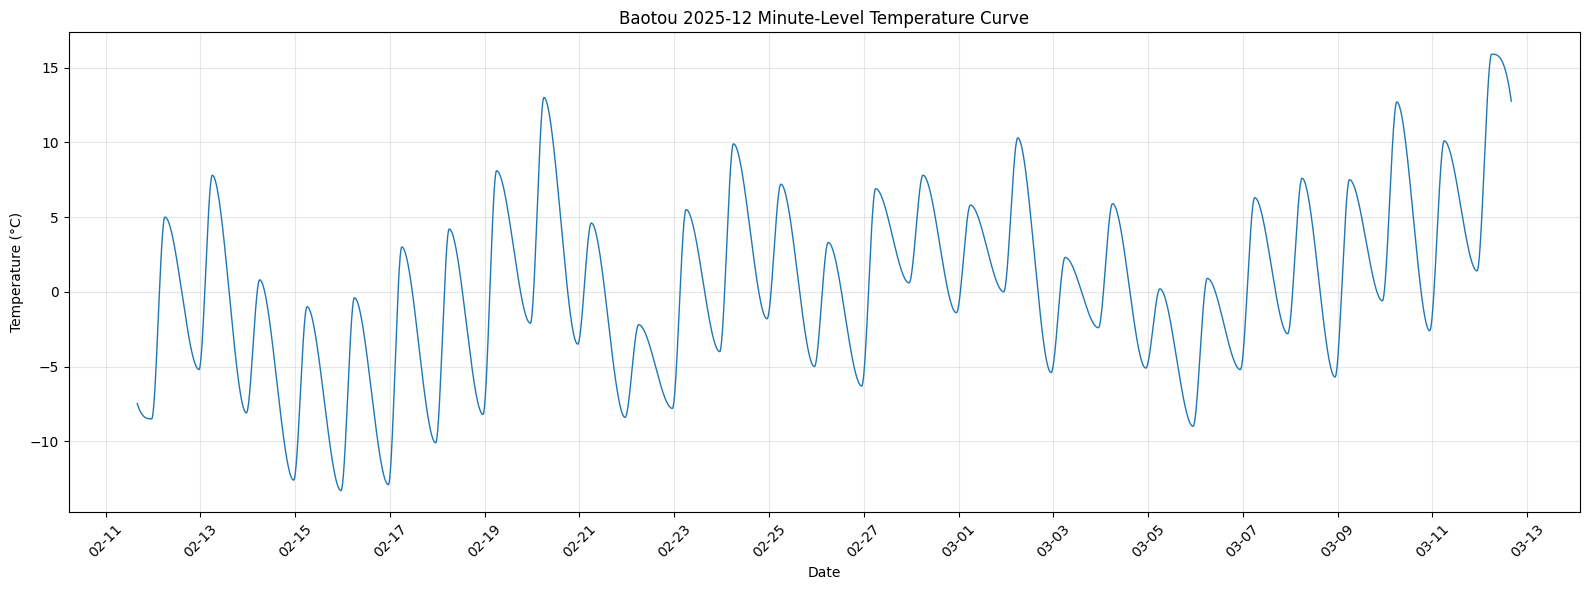

In [7]:
plt.figure(figsize=(16, 6))
plt.plot(minute_df["datetime"], minute_df["temperature_C"], linewidth=1.0)
plt.title("Baotou 2025-12 Minute-Level Temperature Curve")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

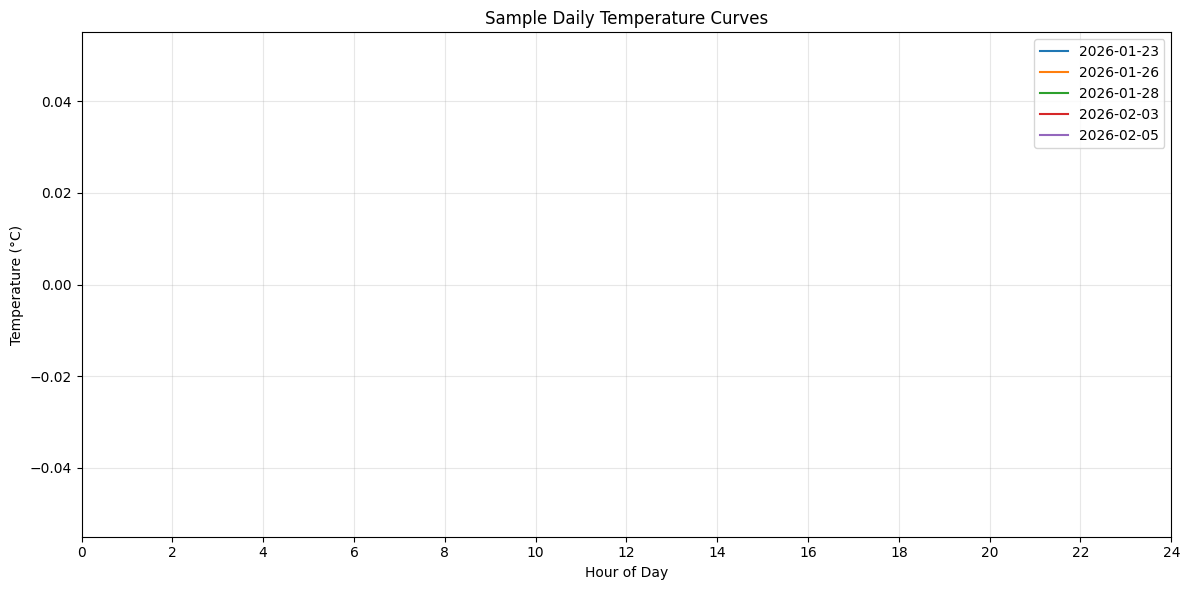

In [8]:
sample_days = [
    date(2026, 1, 23),
    date(2026, 1, 26),
    date(2026, 1, 28),
    date(2026, 2, 3),
    date(2026, 2, 5),
]

plt.figure(figsize=(12, 6))

for d in sample_days:
    part = minute_df[minute_df["date"] == d].copy()
    x = part["datetime"].dt.hour + part["datetime"].dt.minute / 60.0
    y = part["temperature_C"]
    plt.plot(x, y, linewidth=1.5, label=str(d))

plt.title("Sample Daily Temperature Curves")
plt.xlabel("Hour of Day")
plt.ylabel("Temperature (°C)")
plt.xlim(0, 24)
plt.xticks(range(0, 25, 2))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

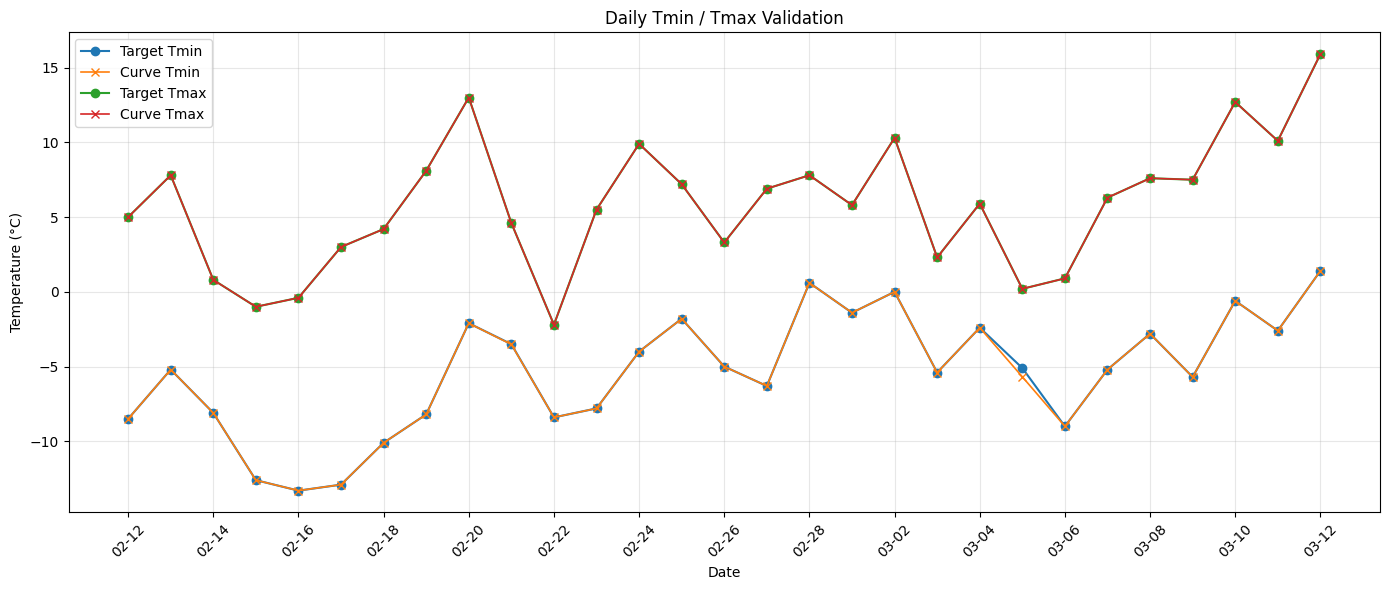

,date,tmin,curve_tmin,min_err,tmax,curve_tmax,max_err
0,2026-02-12,-8.5,-8.500000,5.760974e-10,5.0,5.0,0.0
1,2026-02-13,-5.2,-5.200000,4.566711e-07,7.8,7.8,0.0
2,2026-02-14,-8.1,-8.099997,2.824912e-06,0.8,0.8,0.0
3,2026-02-15,-12.6,-12.599987,1.303912e-05,-1.0,-1.0,0.0
4,2026-02-16,-13.3,-13.299997,2.911644e-06,-0.4,-0.4,0.0
5,2026-02-17,-12.9,-12.900000,2.349947e-07,3.0,3.0,0.0
6,2026-02-18,-10.1,-10.099985,1.479499e-05,4.2,4.2,0.0
7,2026-02-19,-8.2,-8.199997,2.672601e-06,8.1,8.1,0.0
8,2026-02-20,-2.1,-2.099997,2.613892e-06,13.0,13.0,0.0
9,2026-02-21,-3.5,-3.518116,-1.811608e-02,4.6,4.6,0.0


In [9]:
curve_check = (
    minute_df.groupby("date")["temperature_C"]
    .agg(curve_tmin="min", curve_tmax="max")
    .reset_index()
)

check_df = daily_df.merge(curve_check, on="date", how="left")
check_df["min_err"] = check_df["curve_tmin"] - check_df["tmin"]
check_df["max_err"] = check_df["curve_tmax"] - check_df["tmax"]

plt.figure(figsize=(14, 6))
plt.plot(check_df["date"], check_df["tmin"], marker="o", linewidth=1.5, label="Target Tmin")
plt.plot(check_df["date"], check_df["curve_tmin"], marker="x", linewidth=1.2, label="Curve Tmin")
plt.plot(check_df["date"], check_df["tmax"], marker="o", linewidth=1.5, label="Target Tmax")
plt.plot(check_df["date"], check_df["curve_tmax"], marker="x", linewidth=1.2, label="Curve Tmax")

plt.title("Daily Tmin / Tmax Validation")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

check_df[["date", "tmin", "curve_tmin", "min_err", "tmax", "curve_tmax", "max_err"]]

In [10]:
from pathlib import Path
import gzip
import pickle

file_path = r'D:\Devs\Single_Stack_MLJ\data\processed\XINYUAN\包头1000方数据1#2026-02.12-03.12 gzip'

with gzip.open(
    file_path,
    'rb'
) as f:
    df_XY = pickle.load(f)

In [11]:
df_XY[Cols.date_time] = pd.to_datetime(df_XY[Cols.date_time])
df_XY["time_minute"] = df_XY[Cols.date_time].dt.floor("min")

minute_df["time_minute"] = pd.to_datetime(minute_df["datetime"])
minute_df["time_minute"] = minute_df["time_minute"].dt.tz_localize(None).dt.floor("min")

df_XY["time_minute"] = df_XY["time_minute"].dt.tz_localize(None)

temp_map = dict(zip(minute_df["time_minute"], minute_df["temperature_C"]))
df_XY[Cols.temp_environment] = df_XY["time_minute"].map(temp_map)

In [12]:
df_XY

,date_time,HTO,OTH,pressure,voltage,current,temp_H,temp_O,lye_temp,lye_flow,氢分离器液位mm,氧分离器液位mm,液位差mm,temp_out,cell_voltage,current_density,time_minute,temp_environment
0,2026-02-12 13:17:02,0.58,0.18,1.3,551.24,8004.76,80.56,75.78,54.64,55.18,573.09,571.87,0.28,78.170,1.968714,3036.739198,2026-02-12 13:17:00,4.566841
1,2026-02-12 13:18:02,0.58,0.18,1.3,551.24,8002.49,80.62,75.79,54.60,55.18,571.37,571.94,0.22,78.205,1.968714,3035.878036,2026-02-12 13:18:00,4.586013
2,2026-02-12 13:19:02,0.58,0.18,1.3,551.26,8005.69,80.67,75.82,54.59,55.17,571.52,570.71,0.50,78.245,1.968786,3037.092009,2026-02-12 13:19:00,4.604786
3,2026-02-12 13:20:02,0.58,0.17,1.3,551.25,8002.13,80.69,75.86,54.59,55.23,569.68,569.66,2.87,78.275,1.968750,3035.741464,2026-02-12 13:20:00,4.623158
4,2026-02-12 13:21:02,0.57,0.17,1.3,551.19,7998.32,80.66,75.85,54.61,55.18,568.30,567.01,1.67,78.255,1.968536,3034.296077,2026-02-12 13:21:00,4.641126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40318,2026-03-12 13:15:02,1.06,0.07,1.3,505.08,3984.90,80.98,78.57,72.23,58.23,580.80,584.54,0.62,79.775,1.803857,1511.738270,2026-03-12 13:15:00,15.478787
40319,2026-03-12 13:16:02,1.06,0.07,1.3,505.03,3984.97,81.01,78.54,72.20,57.86,584.72,586.76,0.89,79.775,1.803679,1511.764825,2026-03-12 13:16:00,15.496648
40320,2026-03-12 13:17:02,1.06,0.07,1.3,505.10,3984.42,80.99,78.52,72.24,57.74,588.46,590.19,2.26,79.755,1.803929,1511.556173,2026-03-12 13:17:00,15.514150
40321,NaT,NaN,NaN,NaN,NaN,NaN,NaN,78.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN


In [13]:
with gzip.open(file_path, "wb") as handle:
    pickle.dump(df_XY, handle)